In [72]:
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.tree  import DecisionTreeClassifier

import seaborn as sns

In [2]:
df = pd.read_csv('loan.csv')

In [3]:
# over data is simple loan aproved or not of customar based on salary and loan amount features are 
# income , loan Amount , Default means approved or not
df.head()

,Income,Loan Amount,Default
0,15,8,No
1,30,8,No
2,5,9,Yes
3,22,10,No
4,33,12,No


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Income       30 non-null     int64 
 1   Loan Amount  30 non-null     int64 
 2   Default      30 non-null     object
dtypes: int64(2), object(1)
memory usage: 852.0+ bytes


In [6]:
df['Income'].astype('int32')
df['Loan Amount'].astype('int32')

0       8
1       8
2       9
3      10
4      12
5      15
6      20
7      21
8      22
9      30
10     32
11     32
12     35
13     38
14     48
15     50
16     51
17     53
18     70
19     72
20     76
21     78
22     80
23     85
24     89
25     90
26    100
27    105
28    110
29    110
Name: Loan Amount, dtype: int32

In [7]:
df.describe()

,Income,Loan Amount
count,30.000000,30.000000
mean,18.766667,51.966667
std,8.572946,34.055212
min,5.000000,8.000000
25%,13.000000,21.250000
50%,18.000000,49.000000
75%,25.500000,79.500000
max,34.000000,110.000000


{'whiskers': [<matplotlib.lines.Line2D at 0x2d87443d400>,
 'caps': [<matplotlib.lines.Line2D at 0x2d87443d6a0>,
 'boxes': [<matplotlib.lines.Line2D at 0x2d87443d2b0>],
 'medians': [<matplotlib.lines.Line2D at 0x2d87443d940>],
 'fliers': [<matplotlib.lines.Line2D at 0x2d87443da90>],
 'means': []}

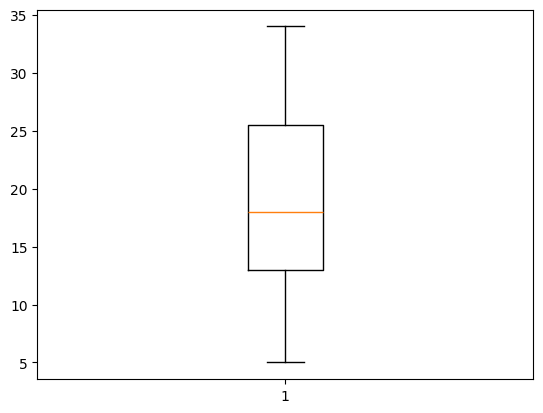

In [15]:
plt.Figure(figsize=(6,8))
plt.boxplot(df['Income']) 

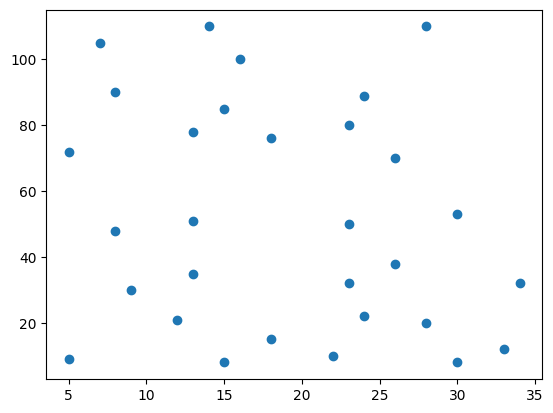

In [21]:
plt.scatter(df['Income'],df['Loan Amount'])

Text(0.5, 1.0, 'income distibution graph')

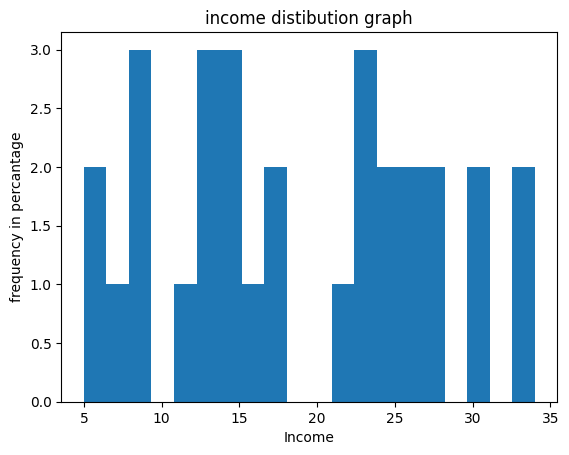

In [22]:
h = df['Income'].plot(kind='hist',bins=20)
h.set_xlabel('Income')
h.set_ylabel("frequency in percantage")
h.set_title("income distibution graph")

In [29]:
df.head(2)

,Income,Loan Amount,Default
0,15,8,No
1,30,8,No
2,5,9,Yes
3,22,10,No
4,33,12,No
5,18,15,No
6,28,20,No
7,12,21,Yes
8,24,22,Yes
9,9,30,Yes


<Axes: ylabel='Density'>

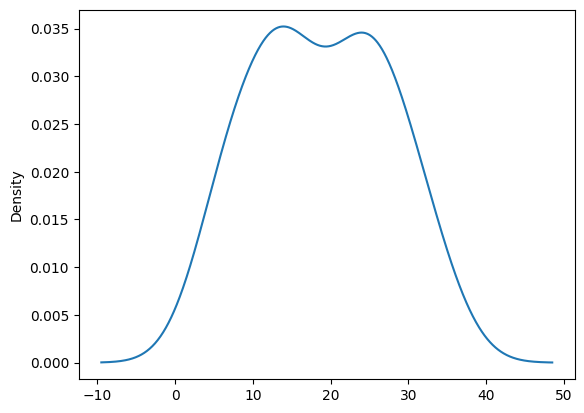

In [23]:
df['Income'].plot(kind='kde')

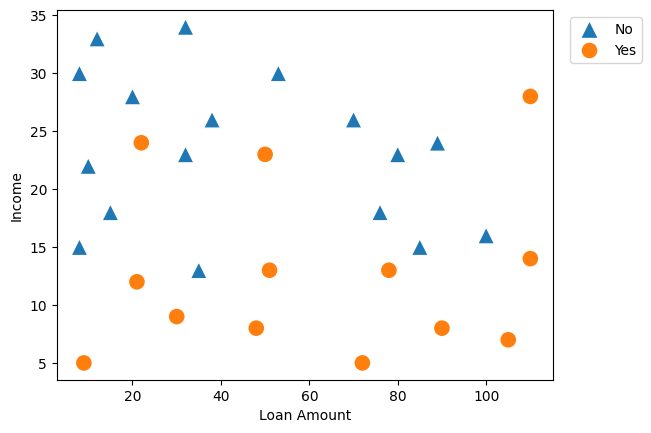

In [82]:
sns.scatterplot(data=df,
                x= 'Loan Amount',
                  y= 'Income',
                  style='Default',
                  hue='Default',
                  markers=['^','o'],
                    s=150)

plt.legend(bbox_to_anchor=(1.02,1), loc='upper left')
plt.show()

In [34]:
model = DecisionTreeClassifier()

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['default'] = le.fit_transform(df['Default'])


In [63]:
X = df[['Income','Loan Amount']]

y = df['default']

pd.get_dummies(X,drop_first=True)


,Income,Loan Amount
0,15,8
1,30,8
2,5,9
3,22,10
4,33,12
5,18,15
6,28,20
7,12,21
8,24,22
9,9,30


In [64]:
from sklearn.model_selection import train_test_split 

x_train , x_test , y_train , y_test = train_test_split(X , y, test_size=0.2 , random_state=2)

In [65]:
x_train.shape

(24, 2)

In [66]:
x_test.shape

(6, 2)

In [67]:
m = model.fit(x_train,y_train)

In [68]:
from sklearn import tree

[Text(0.5, 0.9285714285714286, 'x[0] <= 14.5\ngini = 0.469\nsamples = 24\nvalue = [15, 9]'),
 Text(0.2, 0.7857142857142857, 'x[0] <= 12.5\ngini = 0.245\nsamples = 7\nvalue = [1, 6]'),
 Text(0.35, 0.8571428571428572, 'True  '),
 Text(0.1, 0.6428571428571429, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]'),
 Text(0.3, 0.6428571428571429, 'x[1] <= 43.0\ngini = 0.444\nsamples = 3\nvalue = [1, 2]'),
 Text(0.2, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.4, 0.5, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.8, 0.7857142857142857, 'x[1] <= 105.0\ngini = 0.291\nsamples = 17\nvalue = [14, 3]'),
 Text(0.65, 0.8571428571428572, '  False'),
 Text(0.7, 0.6428571428571429, 'x[1] <= 51.5\ngini = 0.219\nsamples = 16\nvalue = [14, 2]'),
 Text(0.6, 0.5, 'x[1] <= 44.0\ngini = 0.346\nsamples = 9\nvalue = [7, 2]'),
 Text(0.5, 0.35714285714285715, 'x[0] <= 25.0\ngini = 0.219\nsamples = 8\nvalue = [7, 1]'),
 Text(0.4, 0.21428571428571427, 'x[0] <= 23.5\ngini = 0.375\nsamples = 4\nvalue = [3, 1]

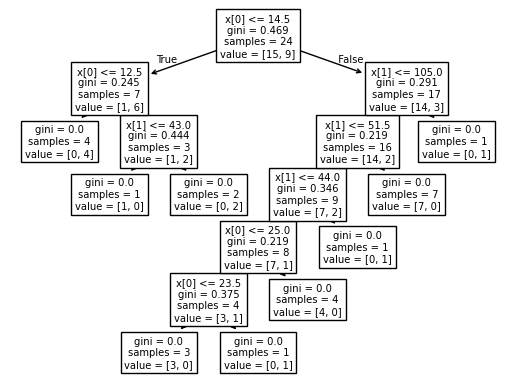

In [69]:
tree.plot_tree(m)

In [70]:
model.score(x_test, y_test)

1.0

c:\Users\dilip\OneDrive\Desktop\ml_learning\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

ImportError: cannot import name 'accuracy' from 'sklearn.model_selection' (c:\Users\dilip\OneDrive\Desktop\ml_learning\.venv\Lib\site-packages\sklearn\model_selection\__init__.py)